#Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

#Loading Data

In [7]:
customer_df=pd.read_csv("Mall_Customers.csv")
print(customer_df)

     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


#Data Analysis

## Data Information

In [8]:
customer_df.info()
print(customer_df.describe())
print(f"customer_df_shpe = {customer_df.shape}")
print(f"customer_df_type = {type(customer_df)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000         

##Missing and duplicate values

In [9]:
null_customer_df = customer_df.isna()
count_null_customer_df = customer_df.isna().sum()
duplicated_customer_df = customer_df.duplicated()
count_duplicated_customer_df = customer_df.duplicated().sum()
print(f"null_customer_df = {null_customer_df}")
print(f"count_null_customer_df = {count_null_customer_df}")
print(f"duplicated_customer_df = {duplicated_customer_df}")
print(f"count_duplicated_customer_df = {count_duplicated_customer_df}")

null_customer_df =      CustomerID  Genre    Age  Annual Income (k$)  Spending Score (1-100)
0         False  False  False               False                   False
1         False  False  False               False                   False
2         False  False  False               False                   False
3         False  False  False               False                   False
4         False  False  False               False                   False
..          ...    ...    ...                 ...                     ...
195       False  False  False               False                   False
196       False  False  False               False                   False
197       False  False  False               False                   False
198       False  False  False               False                   False
199       False  False  False               False                   False

[200 rows x 5 columns]
count_null_customer_df = CustomerID                0
Genre           

#distingushing numerical columns

In [10]:
numeric_df=customer_df.select_dtypes(include='number').columns
print(f"numeric_df = {numeric_df}")

numeric_df = Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')


#Showing data before scaling

##Showing Gunre

Genre
Female    112
Male       88
Name: count, dtype: int64


Text(0.5, 1.0, 'Gender Distribution')

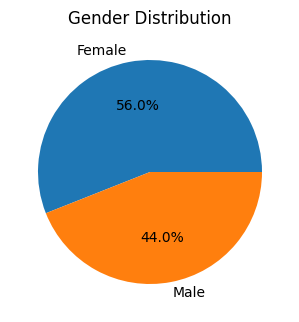

In [17]:
gender_Genre = customer_df["Genre"].value_counts()
print(gender_Genre)
plt.figure(figsize = (15,8))
plt.subplot(2, 2, 1)
plt.pie(gender_Genre.values, labels = gender_Genre.index, autopct = '%1.1f%%')
plt.title('Gender Distribution')

##Age distribution


Text(0.5, 1.0, 'Age Distribution')

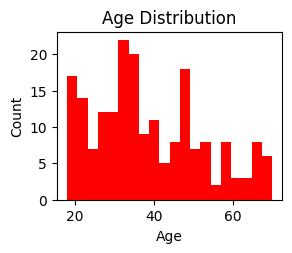

In [18]:
plt.subplot(2, 2, 2)
plt.hist(customer_df['Age'], bins=20, color ="red")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")

##Annual Income distribution

Text(0.5, 1.0, 'Annual Income (k$) Distribution')

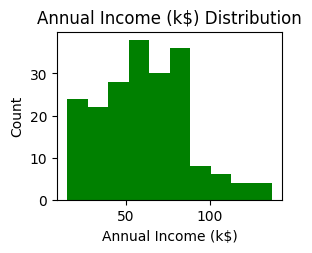

In [19]:
plt.subplot(2, 2, 3)
plt.hist(customer_df['Annual Income (k$)'], bins=10 , color ="green")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Count")
plt.title("Annual Income (k$) Distribution")

##Spending Score (1-100) distribution

/tmp/ipykernel_1897/4019208585.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad= 20, w_pad= 20, h_pad= 20 )


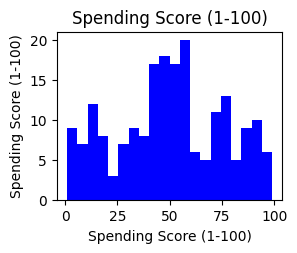

In [20]:
plt.subplot(2, 2, 4)
plt.hist(customer_df['Spending Score (1-100)'], bins=20 , color ="blue")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Spending Score (1-100)")
plt.title("Spending Score (1-100)")
plt.tight_layout(pad= 20, w_pad= 20, h_pad= 20 )
plt.show()

##figure for Age vs Spending Score

Text(0.5, 1.0, 'Age vs Spending Score')

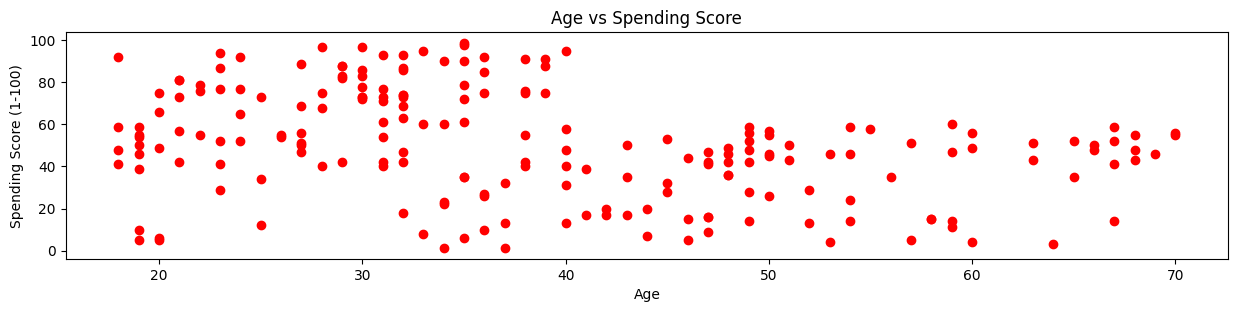

In [21]:
plt.figure(figsize=(15,10))
plt.subplot(3, 1, 1)
plt.scatter(customer_df['Age'] , customer_df['Spending Score (1-100)'], color = 'red')
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.title("Age vs Spending Score")

##Figure for Age vs Annual Income

Text(0.5, 1.0, 'Age vs Annual Income')

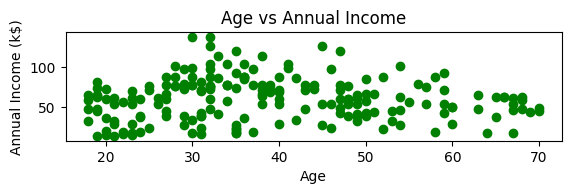

In [22]:
plt.subplot(3, 1, 2)
plt.scatter(customer_df['Age'] , customer_df['Annual Income (k$)'], color = 'green')
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.title("Age vs Annual Income")

##Figure for Annual Income (k$) vs Spending Score

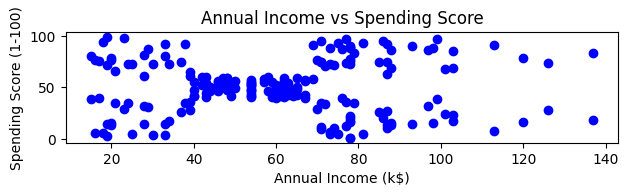

In [23]:
plt.subplot(3, 1, 3)
plt.scatter(customer_df['Annual Income (k$)'] , customer_df['Spending Score (1-100)'], color = 'blue')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")
plt.tight_layout()
plt.show()

#finding outliers

Age                        80.757022
Annual Income (k$)        139.354163
Spending Score (1-100)    127.670565
dtype: float64
Age                       -3.057022
Annual Income (k$)       -18.234163
Spending Score (1-100)   -27.270565
dtype: float64
outlier_numerical_columns =      CustomerID Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           NaN   NaN  NaN                 NaN                     NaN
1           NaN   NaN  NaN                 NaN                     NaN
2           NaN   NaN  NaN                 NaN                     NaN
3           NaN   NaN  NaN                 NaN                     NaN
4           NaN   NaN  NaN                 NaN                     NaN
..          ...   ...  ...                 ...                     ...
195         NaN   NaN  NaN                 NaN                     NaN
196         NaN   NaN  NaN                 NaN                     NaN
197         NaN   NaN  NaN                 NaN                     NaN
198         N

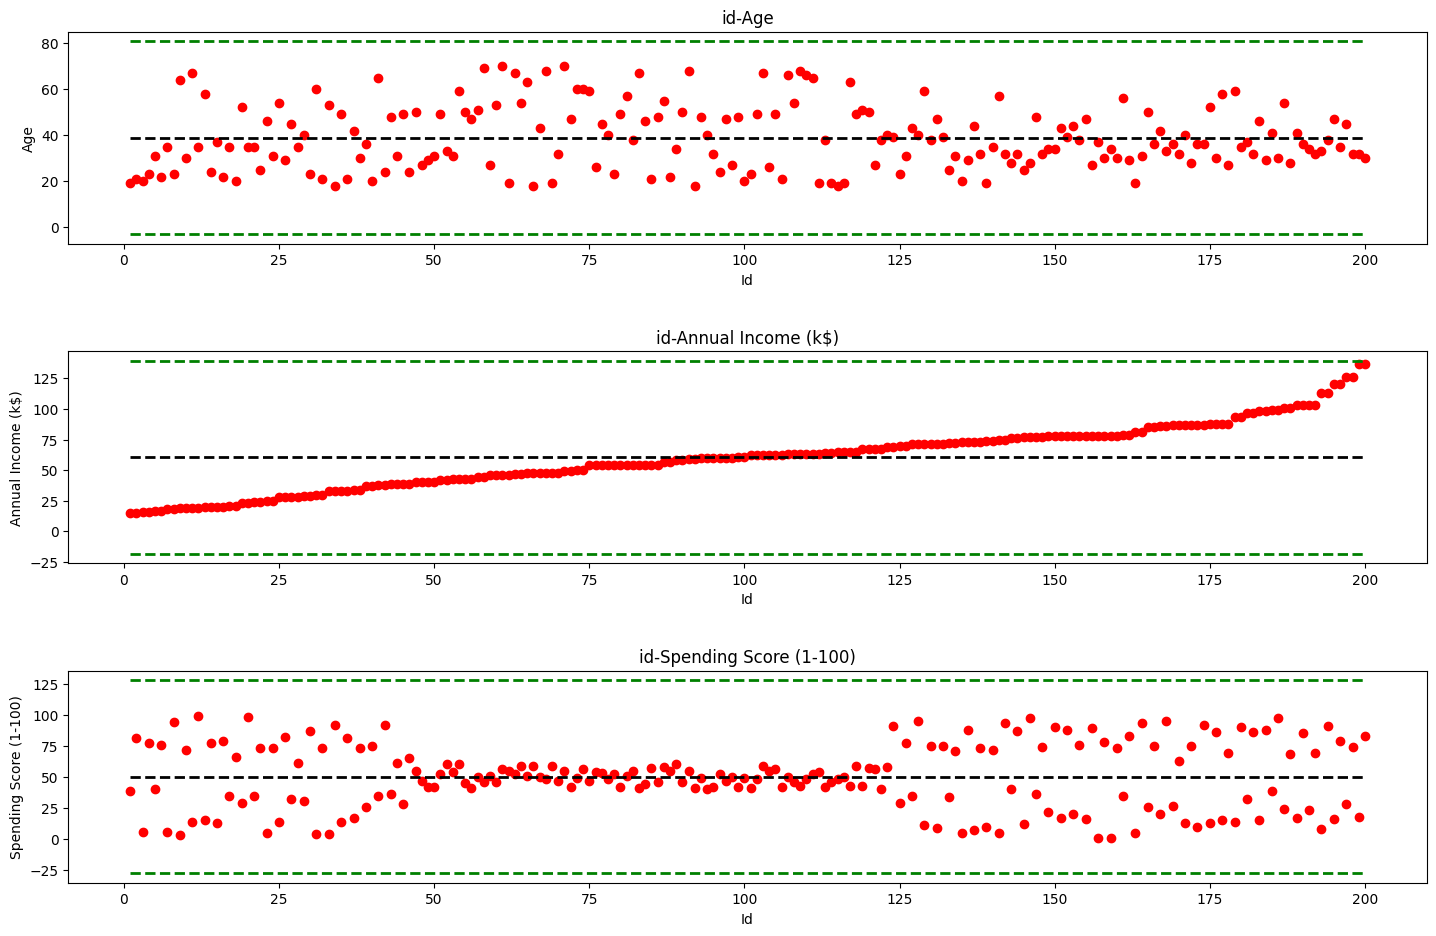

In [24]:
numerical_columns= customer_df.select_dtypes(include = 'number').columns
numerical_columns= numerical_columns[1:]
mean_customer_df= customer_df[numerical_columns].mean()
std_customer_df= customer_df[numerical_columns].std()
upper_band=mean_customer_df+(3*std_customer_df)
lower_band=mean_customer_df-(3*std_customer_df)
print(upper_band)
print(lower_band)
outlier_numerical_columns=customer_df[((customer_df[numerical_columns]<lower_band) |
                                      (customer_df[numerical_columns]> upper_band))]
outlier_ID=np.where((customer_df[numerical_columns]<lower_band) |
                                      (customer_df[numerical_columns]> upper_band))
print(f"outlier_numerical_columns = {outlier_numerical_columns}")
print(f"outlier_ID = {outlier_ID}")
plt.figure(figsize=(15,10))
for k in range (len(numerical_columns)):
    plt.subplot(3, 1, k+1)
    plt.scatter(customer_df['CustomerID'] , customer_df[numerical_columns[k]], color = 'red')
    plt.hlines(mean_customer_df[numerical_columns[k]],
            xmin=customer_df['CustomerID'].min() ,
            xmax=customer_df['CustomerID'].max(),
            color='black',
            linestyle='--',
            linewidth=2)
    plt.hlines(upper_band[numerical_columns[k]],
            xmin=customer_df['CustomerID'].min() ,
            xmax=customer_df['CustomerID'].max(),
            color='green',
            linestyle='--',
            linewidth=2)
    plt.hlines(lower_band[numerical_columns[k]],
            xmin=customer_df['CustomerID'].min() ,
            xmax=customer_df['CustomerID'].max(),
            color='green',
            linestyle='--',
            linewidth=2)
    plt.xlabel("Id")
    plt.ylabel(numerical_columns[k])
    plt.title("id" + "-" + numerical_columns[k])
plt.tight_layout(pad=3 , h_pad=3, w_pad=2)
plt.show()

#Saling with Standard Scaler

          Age  Annual Income (k$)  Spending Score (1-100)
0   -1.424569           -1.738999               -0.434801
1   -1.281035           -1.738999                1.195704
2   -1.352802           -1.700830               -1.715913
3   -1.137502           -1.700830                1.040418
4   -0.563369           -1.662660               -0.395980
..        ...                 ...                     ...
195 -0.276302            2.268791                1.118061
196  0.441365            2.497807               -0.861839
197 -0.491602            2.497807                0.923953
198 -0.491602            2.917671               -1.250054
199 -0.635135            2.917671                1.273347

[200 rows x 3 columns]
coustomer_df_scaler_mean =
 Age                      -1.021405e-16
Annual Income (k$)       -2.131628e-16
Spending Score (1-100)   -1.465494e-16
dtype: float64
coustomer_df_scaler_std =
 Age                       1.002509
Annual Income (k$)        1.002509
Spending Score (1-100) 

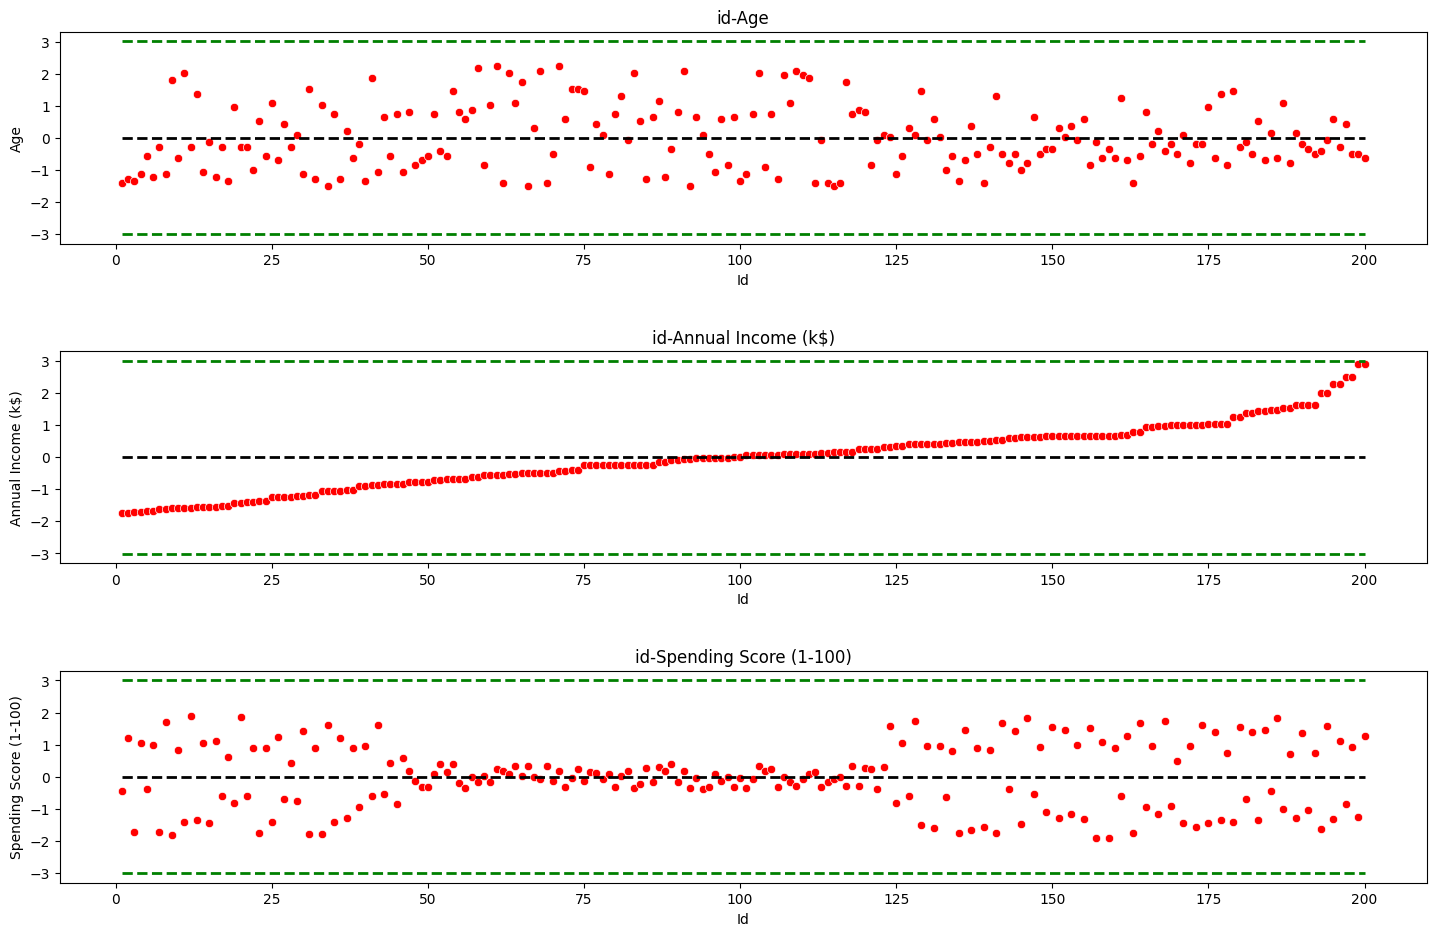

In [25]:
scaler=StandardScaler()
customer_df_scaler = scaler.fit_transform(customer_df[numerical_columns]) #   the type of date chage to numpy array
customer_df_scaler = pd.DataFrame(customer_df_scaler, columns=numerical_columns)
print(customer_df_scaler)
customer_df_scaler_mean= customer_df_scaler[numerical_columns].mean()
customer_df_scaler_std= customer_df_scaler[numerical_columns].std()
upper_band_scaler=customer_df_scaler_mean+(3*customer_df_scaler_std)
lower_band_scaler=customer_df_scaler_mean-(3*customer_df_scaler_std)
print(f"coustomer_df_scaler_mean =\n {customer_df_scaler_mean}")
print(f"coustomer_df_scaler_std =\n {customer_df_scaler_std}")
outlier_numerical_columns_scaler=customer_df_scaler[((customer_df_scaler [numerical_columns]<lower_band_scaler) |
                                      (customer_df_scaler [numerical_columns]> upper_band_scaler))]
outlier_ID = np.where((customer_df_scaler[numerical_columns] < lower_band_scaler) |
                      (customer_df_scaler[numerical_columns] > upper_band_scaler))
print(f"outlier_numerical_columns = {outlier_numerical_columns_scaler}")
print(f"outlier_ID = {outlier_ID}")
plt.figure(figsize=(15,10))
for i in range (len(numerical_columns)):
    plt.subplot(3, 1, i+1)
    sns.scatterplot(x=customer_df['CustomerID'], y=customer_df_scaler[numerical_columns[i]] , color='red')
    plt.title(numerical_columns[i])

    plt.hlines(customer_df_scaler_mean[numerical_columns[i]],
            xmin=customer_df['CustomerID'].min() ,
            xmax=customer_df['CustomerID'].max(),
            color='black',
            linestyle='--',
            linewidth=2)
    plt.hlines(upper_band_scaler[numerical_columns[i]],
            xmin=customer_df['CustomerID'].min() ,
            xmax=customer_df['CustomerID'].max(),
            color='green',
            linestyle='--',
            linewidth=2)
    plt.hlines(lower_band_scaler[numerical_columns[i]],
            xmin=customer_df['CustomerID'].min() ,
            xmax=customer_df['CustomerID'].max(),
            color='green',
            linestyle='--',
            linewidth=2)
    plt.xlabel("Id")
    plt.ylabel(numerical_columns[i])
    plt.title("id" + "-" + numerical_columns[i])
plt.tight_layout(pad=3 , h_pad=3, w_pad=2)
plt.show()

#Correlation for Customer_df(before scaling)

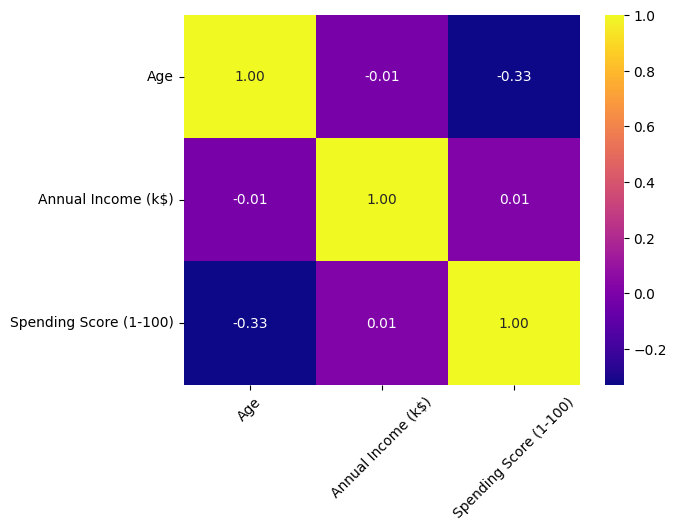

In [26]:
customer_df_corr = customer_df[numerical_columns].corr()
sns.heatmap(customer_df_corr, annot=True, fmt="0.2f", cmap="plasma")
plt.xticks(rotation=45)
plt.show()

correlation for customer_df_scaler(after scaling)

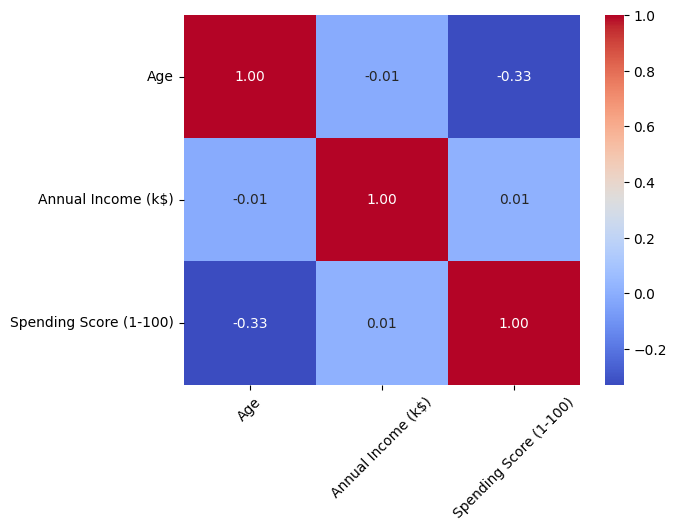

In [27]:
customer_df_corr = customer_df_scaler[numerical_columns].corr()
sns.heatmap(customer_df_corr, annot=True, fmt="0.2f", cmap="coolwarm")
plt.xticks(rotation=45)
plt.show()